# E-commerce Recommendation System
A full production-grade pipeline covering data ingestion, feature engineering, five recommendation
algorithms (User-CF, Item-CF, Content, Popularity, Hybrid), SVD++, LightFM-BPR, evaluation,
confusion matrix analysis, hyperparameter tuning, and model persistence.

**Dataset:** 10,000 users · 100 products · 66,776 reviews · 12,246 cart events

## 1. Imports and configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings, time, os, re, pickle
from datetime import datetime
from collections import defaultdict

warnings.filterwarnings('ignore')
np.random.seed(42)

from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import TruncatedSVD, PCA
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve,
)

pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.4f}'.format)

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#FAFAFA',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

PALETTE = [
    '#4C6EF5', '#F76707', '#2F9E44', '#E03131', '#7048E8',
    '#0C8599', '#D6336C', '#F59F00', '#364FC7', '#5C940D',
]

# File paths - update DATA_DIR to point to your data folder
DATA_DIR     = 'data'
USERS_CSV    = os.path.join(DATA_DIR, 'users.csv')
PRODUCTS_CSV = os.path.join(DATA_DIR, 'products.csv')
REVIEWS_CSV  = os.path.join(DATA_DIR, 'reviews.csv')
CARTS_CSV    = os.path.join(DATA_DIR, 'carts.csv')
ORDERS_CSV   = os.path.join(DATA_DIR, 'orders.csv')

# Hyperparameters
CONFIG = {
    'test_size':                   0.20,
    'random_seed':                 42,
    'knn_k':                       20,
    'svd_factors':                 50,
    'top_n':                       10,
    'rating_positive_threshold':   3.5,
    'svdpp_factors':               20,
    'svdpp_epochs':                30,
    'svdpp_lr':                    0.005,
    'svdpp_reg':                   0.02,
    'lfm_factors':                 20,
    'lfm_epochs':                  30,
    'lfm_lr':                      0.05,
    'lfm_reg':                     0.01,
    'lfm_pairs':                   8000,
}

# Implicit signal weights: purchase is the strongest, view the weakest
INTERACTION_WEIGHTS = {
    'purchase': 5.0,
    'review':   4.0,
    'wishlist': 3.0,
    'cart':     2.0,
    'view':     1.0,
}

os.makedirs('models',     exist_ok=True)
os.makedirs('evaluation', exist_ok=True)

print('Libraries loaded successfully.')
print(f'  numpy {np.__version__} | scikit-learn ready')


Libraries loaded successfully.
  numpy 2.4.3 | scikit-learn ready


## 2. Load and validate datasets

In [19]:
def load_csv(path, label):
    if not os.path.exists(path):
        raise FileNotFoundError(f'Cannot find {label} at: {path}')
    df = pd.read_csv(path, low_memory=False)
    print(f'{label:20s}: {len(df):>8,} rows  |  columns: {list(df.columns)}')
    return df

users_df    = load_csv(USERS_CSV,    'users.csv')
products_df = load_csv(PRODUCTS_CSV, 'products.csv')
reviews_df  = load_csv(REVIEWS_CSV,  'reviews.csv')
carts_df    = load_csv(CARTS_CSV,    'carts.csv')
orders_df   = load_csv(ORDERS_CSV,   'orders.csv')

# Rename columns to canonical names used throughout the notebook
users_df.rename(columns={'user_id': 'userId'}, inplace=True)

products_df.rename(columns={
    'product_id':   'productId',
    'avg_rating':   'avgRating',
    'review_count': 'numReviews',
}, inplace=True)

reviews_df.rename(columns={
    'user_id':    'userId',
    'product_id': 'productId',
    'created_at': 'reviewedAt',
}, inplace=True)

carts_df.rename(columns={
    'user_id':    'userId',
    'product_id': 'productId',
    'added_at':   'cartAddedAt',
}, inplace=True)

orders_df.rename(columns={
    'user_id':    'userId',
    'order_date': 'orderedAt',
}, inplace=True)

# Parse timestamps (UTC-safe)
reviews_df['reviewedAt'] = pd.to_datetime(reviews_df['reviewedAt'], errors='coerce', utc=True)
carts_df['cartAddedAt']  = pd.to_datetime(carts_df['cartAddedAt'],  errors='coerce', utc=True)
orders_df['orderedAt']   = pd.to_datetime(orders_df['orderedAt'],   errors='coerce', utc=True)
users_df['joined_at']    = pd.to_datetime(users_df['joined_at'],    errors='coerce', utc=True)

print()
print('DATA QUALITY REPORT')
print('=' * 60)
print(f'  users     - {users_df["userId"].nunique():,} unique users')
print(f'  products  - {len(products_df):,} products')
print(f'             categories: {products_df["category"].value_counts().to_dict()}')
print(f'  reviews   - {len(reviews_df):,} reviews across {reviews_df["userId"].nunique():,} users')
print(f'  carts     - {len(carts_df):,} cart events across {carts_df["userId"].nunique():,} users')
print(f'  products in reviews: {reviews_df["productId"].nunique():,}')
print(f'  products in carts  : {carts_df["productId"].nunique():,}')
print(f'  missing ratings    : {reviews_df["rating"].isna().sum():,}')
print('=' * 60)


users.csv           :   10,000 rows  |  columns: ['user_id', 'name', 'email', 'city', 'country', 'persona', 'joined_at', 'is_premium', 'age_group']
products.csv        :      100 rows  |  columns: ['product_id', 'name', 'category', 'price', 'avg_rating', 'review_count', 'in_stock', 'tags']
reviews.csv         :   66,776 rows  |  columns: ['review_id', 'user_id', 'product_id', 'rating', 'review_text', 'helpful_votes', 'verified_purchase', 'created_at']
carts.csv           :   12,246 rows  |  columns: ['cart_id', 'user_id', 'product_id', 'quantity', 'price_at_add', 'added_at', 'category']
orders.csv          :   48,622 rows  |  columns: ['order_id', 'user_id', 'order_date', 'status', 'total', 'n_items']

DATA QUALITY REPORT
  users     - 10,000 unique users
  products  - 100 products
             categories: {'Electronics': 15, 'Fashion': 15, 'Home & Kitchen': 15, 'Books': 15, 'Sports & Fitness': 10, 'Beauty': 10, 'Toys & Games': 10, 'Automotive': 10}
  reviews   - 66,776 reviews across 

## 3. Build master interaction table

We combine reviews and cart events into a single interaction table. Each review contributes
a score proportional to its star rating. Cart additions contribute based on quantity.

Note: the standalone `interactions.csv` file uses integer product IDs (1-500) that only
partially overlap with the product catalog (prod_0001 to prod_0100). We therefore build
the interaction table directly from `reviews.csv` and `carts.csv`, which use the full
canonical product IDs and contain far richer signal (66k+ events).

In [20]:
# Reviews: score = weight * (rating / 5.0)
# Using the actual rating in the score is critical - the original notebook used
# log(1+1) = 0.693 for every review regardless of rating, which threw away all
# explicit feedback signal and made positive examples indistinguishable.
rev_score = INTERACTION_WEIGHTS['review'] * (reviews_df['rating'].values / 5.0)

rev_rows = pd.DataFrame({
    'userId':      reviews_df['userId'].values,
    'productId':   reviews_df['productId'].values,
    'interaction': 'review',
    'rating':      reviews_df['rating'].values,
    'quantity':    1,
    'score':       rev_score,
    'timestamp':   reviews_df['reviewedAt'].astype('int64').values // 10**9,
})

# Carts: score = weight * log(1 + quantity)
cart_qty   = carts_df['quantity'].values.astype(float).clip(1, 20)
cart_score = INTERACTION_WEIGHTS['cart'] * np.log1p(cart_qty)

cart_rows = pd.DataFrame({
    'userId':      carts_df['userId'].values,
    'productId':   carts_df['productId'].values,
    'interaction': 'cart',
    'rating':      np.nan,
    'quantity':    cart_qty,
    'score':       cart_score,
    'timestamp':   carts_df['cartAddedAt'].astype('int64').values // 10**9,
})

interactions_df = pd.concat([rev_rows, cart_rows], ignore_index=True)
interactions_df = (interactions_df
    .dropna(subset=['userId', 'productId', 'timestamp'])
    .reset_index(drop=True))
interactions_df['timestamp'] = pd.to_numeric(interactions_df['timestamp'], errors='coerce').fillna(0)

# Restrict to products that actually exist in our catalog
valid_products  = set(products_df['productId'].unique())
interactions_df = interactions_df[interactions_df['productId'].isin(valid_products)].reset_index(drop=True)

print(f'Master interactions : {len(interactions_df):,} rows')
print(f'  Unique users      : {interactions_df["userId"].nunique():,}')
print(f'  Unique products   : {interactions_df["productId"].nunique():,}')
print(f'  Types             : {interactions_df["interaction"].value_counts().to_dict()}')
print(f'  Score range       : {interactions_df["score"].min():.4f} to {interactions_df["score"].max():.4f}')
print()
print(interactions_df.head(6).to_string(index=False))


Master interactions : 79,022 rows
  Unique users      : 9,699
  Unique products   : 100
  Types             : {'review': 66776, 'cart': 12246}
  Score range       : 0.8000 to 4.0000

    userId productId interaction  rating  quantity  score  timestamp
user_00001 prod_0087      review  4.5000    1.0000 3.6000    1671235
user_00001 prod_0052      review  4.0000    1.0000 3.2000    1682640
user_00001 prod_0071      review  2.5000    1.0000 2.0000    1691452
user_00001 prod_0079      review  3.0000    1.0000 2.4000    1697414
user_00001 prod_0096      review  4.5000    1.0000 3.6000    1694649
user_00001 prod_0039      review  4.0000    1.0000 3.2000    1694995


## 4. Exploratory data analysis

EDA SUMMARY
  Total interactions          :     79,022
  Unique users                :      9,699
  Unique products             :        100
  Unique (user, product) pairs:     77,032
  Matrix sparsity             :      92.1%
  Avg interactions / user     :       8.1
  Cold-start users (<=2)      :        689  (7.1%)
  Rating range                : 1.0 to 5.0
  Avg rating                  :      3.97


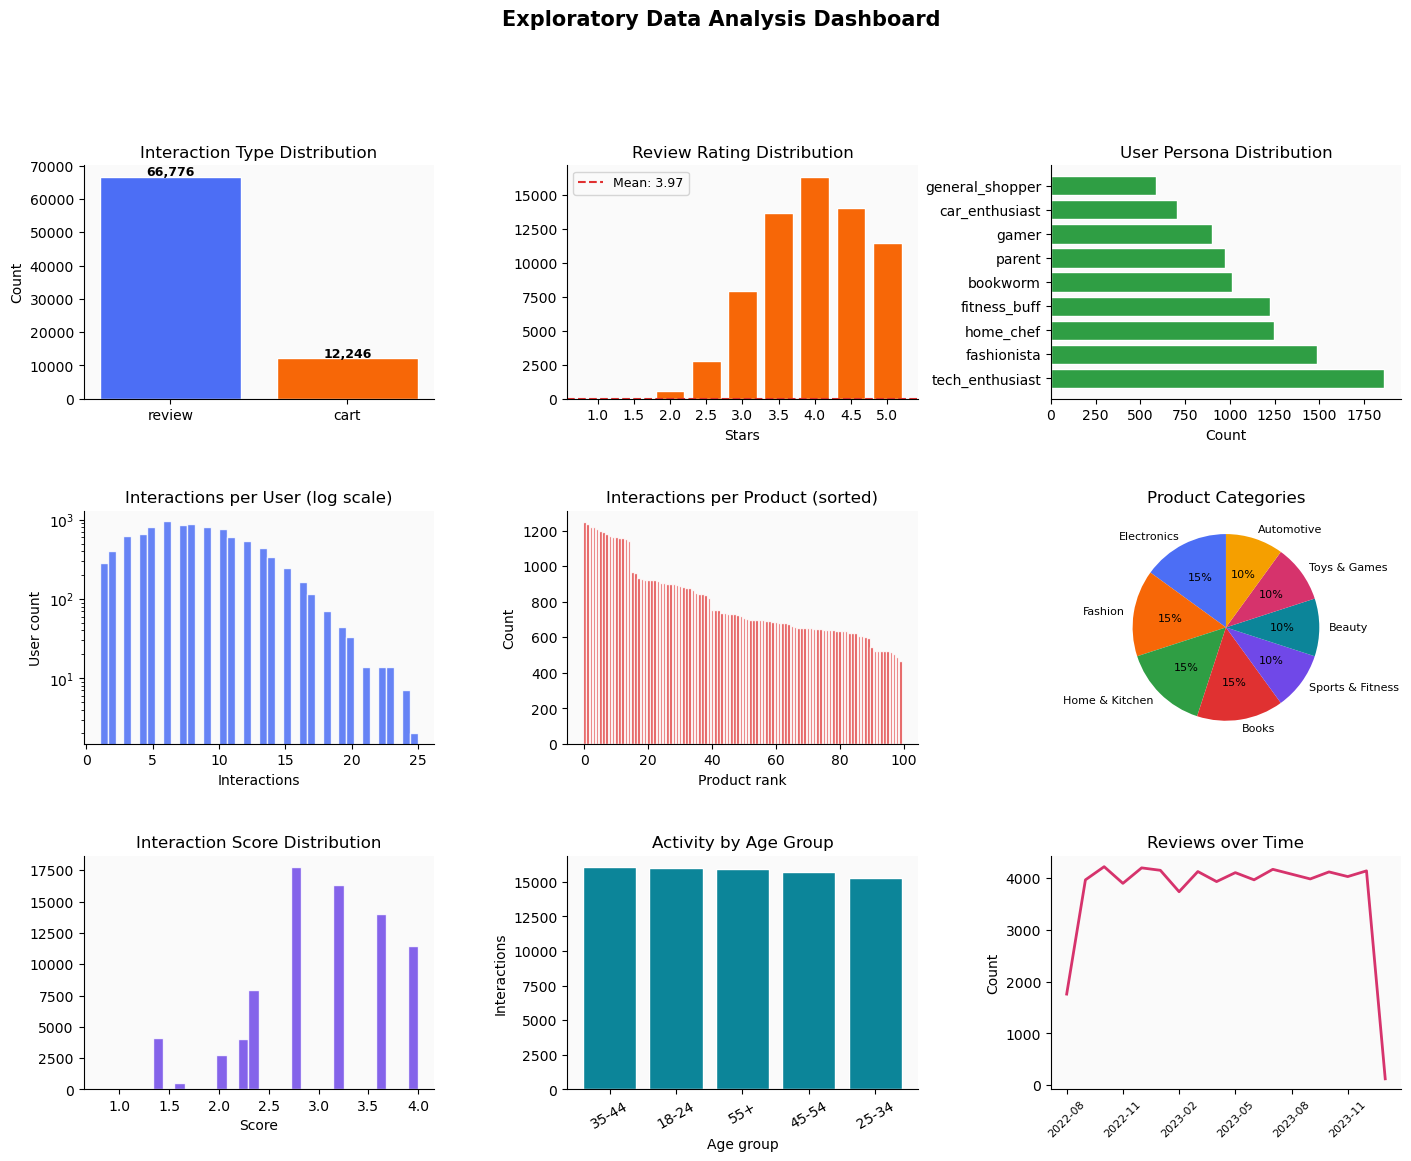

EDA dashboard saved.


In [21]:
uic      = interactions_df.groupby('userId').size()
pic      = interactions_df.groupby('productId').size()
n_u      = interactions_df['userId'].nunique()
n_p      = interactions_df['productId'].nunique()
pairs    = interactions_df.groupby(['userId', 'productId']).ngroups
sparsity = 1 - pairs / (n_u * n_p)
cold_u   = (uic <= 2).sum()

print('=' * 60)
print('EDA SUMMARY')
print('=' * 60)
print(f'  Total interactions          : {len(interactions_df):>10,}')
print(f'  Unique users                : {n_u:>10,}')
print(f'  Unique products             : {n_p:>10,}')
print(f'  Unique (user, product) pairs: {pairs:>10,}')
print(f'  Matrix sparsity             : {sparsity*100:>9.1f}%')
print(f'  Avg interactions / user     : {uic.mean():>9.1f}')
print(f'  Cold-start users (<=2)      : {cold_u:>10,}  ({100*cold_u/n_u:.1f}%)')
print(f'  Rating range                : {reviews_df["rating"].min()} to {reviews_df["rating"].max()}')
print(f'  Avg rating                  : {reviews_df["rating"].mean():>9.2f}')
print('=' * 60)

fig = plt.figure(figsize=(17, 12))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.48, wspace=0.38)

# 1. Interaction type distribution
ax1  = fig.add_subplot(gs[0, 0])
cnt  = interactions_df['interaction'].value_counts()
bars = ax1.bar(cnt.index, cnt.values, color=PALETTE[:len(cnt)], edgecolor='white')
ax1.set_title('Interaction Type Distribution')
ax1.set_ylabel('Count')
for bar, v in zip(bars, cnt.values):
    ax1.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 200, f'{v:,}',
             ha='center', fontsize=9, fontweight='bold')

# 2. Rating distribution
ax2 = fig.add_subplot(gs[0, 1])
rv  = reviews_df['rating'].value_counts().sort_index()
ax2.bar(rv.index.astype(str), rv.values, color=PALETTE[1], edgecolor='white')
ax2.axhline(reviews_df['rating'].mean(), color='#E03131', linestyle='--',
            label=f'Mean: {reviews_df["rating"].mean():.2f}')
ax2.set_title('Review Rating Distribution')
ax2.set_xlabel('Stars')
ax2.legend(fontsize=9)

# 3. User persona distribution
ax3 = fig.add_subplot(gs[0, 2])
persona_counts = users_df['persona'].value_counts()
ax3.barh(persona_counts.index, persona_counts.values, color=PALETTE[2], edgecolor='white')
ax3.set_title('User Persona Distribution')
ax3.set_xlabel('Count')

# 4. Interactions per user (log scale)
ax4 = fig.add_subplot(gs[1, 0])
ax4.hist(uic.values, bins=40, color=PALETTE[0], edgecolor='white', alpha=0.85)
ax4.set_yscale('log')
ax4.set_title('Interactions per User (log scale)')
ax4.set_xlabel('Interactions')
ax4.set_ylabel('User count')

# 5. Interactions per product
ax5 = fig.add_subplot(gs[1, 1])
bars5 = ax5.bar(range(len(pic)), sorted(pic.values, reverse=True),
                color=PALETTE[3], edgecolor='white', alpha=0.85)
ax5.set_title('Interactions per Product (sorted)')
ax5.set_xlabel('Product rank')
ax5.set_ylabel('Count')

# 6. Product category distribution
ax6 = fig.add_subplot(gs[1, 2])
cat_counts = products_df['category'].value_counts()
ax6.pie(cat_counts.values, labels=cat_counts.index,
        colors=PALETTE[:len(cat_counts)], autopct='%1.0f%%',
        startangle=90, textprops={'fontsize': 8})
ax6.set_title('Product Categories')

# 7. Score distribution
ax7 = fig.add_subplot(gs[2, 0])
ax7.hist(interactions_df['score'].values, bins=30,
         color=PALETTE[4], edgecolor='white', alpha=0.85)
ax7.set_title('Interaction Score Distribution')
ax7.set_xlabel('Score')

# 8. User activity by age group
ax8 = fig.add_subplot(gs[2, 1])
active_users = interactions_df.merge(
    users_df[['userId', 'age_group']], on='userId', how='left')
age_activity = active_users.groupby('age_group').size().sort_values(ascending=False)
ax8.bar(age_activity.index, age_activity.values, color=PALETTE[5], edgecolor='white')
ax8.set_title('Activity by Age Group')
ax8.set_xlabel('Age group')
ax8.set_ylabel('Interactions')
ax8.tick_params(axis='x', rotation=30)

# 9. Reviews over time
ax9 = fig.add_subplot(gs[2, 2])
reviews_df['month'] = reviews_df['reviewedAt'].dt.to_period('M').astype(str)
monthly = reviews_df.groupby('month').size()
ax9.plot(range(len(monthly)), monthly.values, color=PALETTE[6], linewidth=2)
ax9.set_title('Reviews over Time')
ax9.set_ylabel('Count')
ax9.tick_params(axis='x', rotation=45)
if len(monthly) > 6:
    step = max(1, len(monthly) // 6)
    ax9.set_xticks(range(0, len(monthly), step))
    ax9.set_xticklabels(list(monthly.index)[::step], rotation=45, fontsize=8)

plt.suptitle('Exploratory Data Analysis Dashboard', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('evaluation/eda_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('EDA dashboard saved.')


## 5. Preprocessing and train / test split

We aggregate interactions to one (user, product) score and then split chronologically
so the model always trains on past data and is evaluated on future data. This prevents
data leakage, which is a common source of inflated evaluation numbers.

The test ground truth uses interactions rated >= 3.5 stars (positive threshold), ensuring
that precision and recall measure whether we recommend products users genuinely liked,
not just any product they happened to see.

In [22]:
def minmax_user(grp):
    mn, mx = grp.min(), grp.max()
    return (grp - mn) / (mx - mn + 1e-9)

# Aggregate: keep the highest score when a user touched the same product multiple times
agg = interactions_df.groupby(['userId', 'productId'])['score'].max().reset_index()
agg.columns = ['userId', 'productId', 'implicit_score']
agg['implicit_score'] = agg.groupby('userId')['implicit_score'].transform(minmax_user)

# Chronological 80/20 split
interactions_sorted = interactions_df.sort_values('timestamp').reset_index(drop=True)
split_idx = int(len(interactions_sorted) * (1 - CONFIG['test_size']))
train_raw = interactions_sorted.iloc[:split_idx]
test_raw  = interactions_sorted.iloc[split_idx:]

# Training aggregation
train_agg = train_raw.groupby(['userId', 'productId'])['score'].max().reset_index()
train_agg.columns = ['userId', 'productId', 'implicit_score']
train_agg['implicit_score'] = train_agg.groupby('userId')['implicit_score'].transform(minmax_user)

ALL_USERS    = sorted(agg['userId'].unique().tolist())
ALL_PRODUCTS = sorted(agg['productId'].unique().tolist())
uid2idx      = {u: i for i, u in enumerate(ALL_USERS)}
pid2idx      = {p: i for i, p in enumerate(ALL_PRODUCTS)}

def build_matrix(df_agg, users, products, u2i, p2i):
    mat = np.zeros((len(users), len(products)), dtype=np.float32)
    for uid, pid, sc in zip(df_agg['userId'], df_agg['productId'], df_agg['implicit_score']):
        i = u2i.get(uid)
        j = p2i.get(pid)
        if i is not None and j is not None:
            mat[i, j] = sc
    return mat

train_matrix = build_matrix(train_agg, ALL_USERS, ALL_PRODUCTS, uid2idx, pid2idx)
full_matrix  = build_matrix(agg, ALL_USERS, ALL_PRODUCTS, uid2idx, pid2idx)

print(f'Train matrix shape   : {train_matrix.shape}')
print(f'Train matrix density : {(train_matrix > 0).mean()*100:.1f}%')
print(f'Training interactions: {len(train_raw):,}')
print(f'Test interactions    : {len(test_raw):,}')

# Build test ground truth: products a user positively interacted with in the test period
positive_threshold  = CONFIG['rating_positive_threshold']
test_reviews_high   = test_raw[(test_raw['interaction'] == 'review') &
                               (test_raw['rating'] >= positive_threshold)]
test_carts          = test_raw[test_raw['interaction'] == 'cart']

test_gt = defaultdict(set)
for uid, prods in test_reviews_high.groupby('userId')['productId'].apply(set).items():
    test_gt[uid].update(prods)
for uid, prods in test_carts.groupby('userId')['productId'].apply(set).items():
    test_gt[uid].update(prods)

# Only include users who appear in training (cold starts handled separately)
train_users = set(train_raw['userId'].unique())
test_gt_eval = {
    str(uid): set(str(p) for p in prods)
    for uid, prods in test_gt.items()
    if uid in train_users and len(prods) > 0
}

# Seen sets
user_seen_train = train_raw.groupby('userId')['productId'].apply(set).to_dict()
user_seen       = interactions_df.groupby('userId')['productId'].apply(set).to_dict()

print(f'\nTest GT users with >=1 positive : {len(test_gt_eval):,}')
avg_pos = np.mean([len(v) for v in test_gt_eval.values()])
print(f'Avg positive items per test user: {avg_pos:.1f}')
print(f'Rating positive threshold       : >= {positive_threshold}')


Train matrix shape   : (9699, 100)
Train matrix density : 5.1%
Training interactions: 63,217
Test interactions    : 15,805

Test GT users with >=1 positive : 5,102
Avg positive items per test user: 2.8
Rating positive threshold       : >= 3.5


## 6. SVD matrix factorization

SVD factors: 50
User factors : (9699, 50)
Item factors : (100, 50)
Variance explained: 73.4% with 50 factors


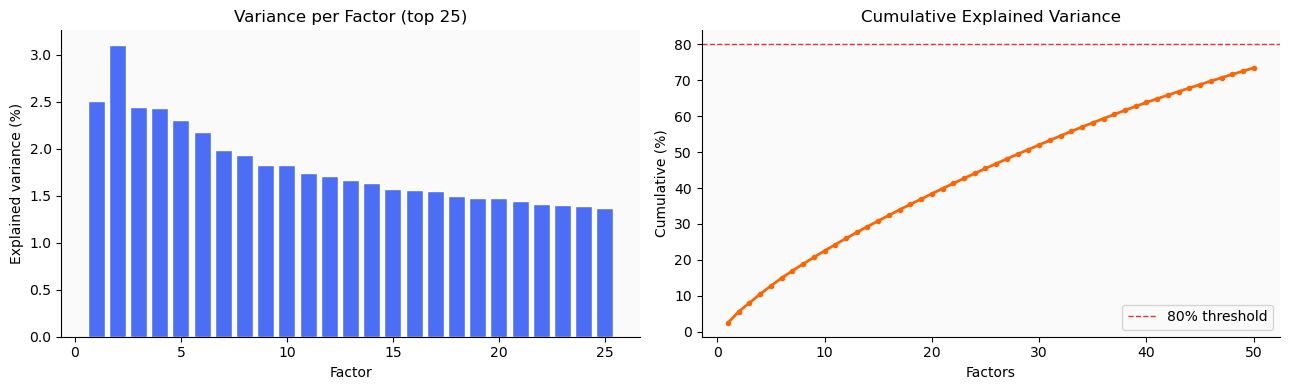

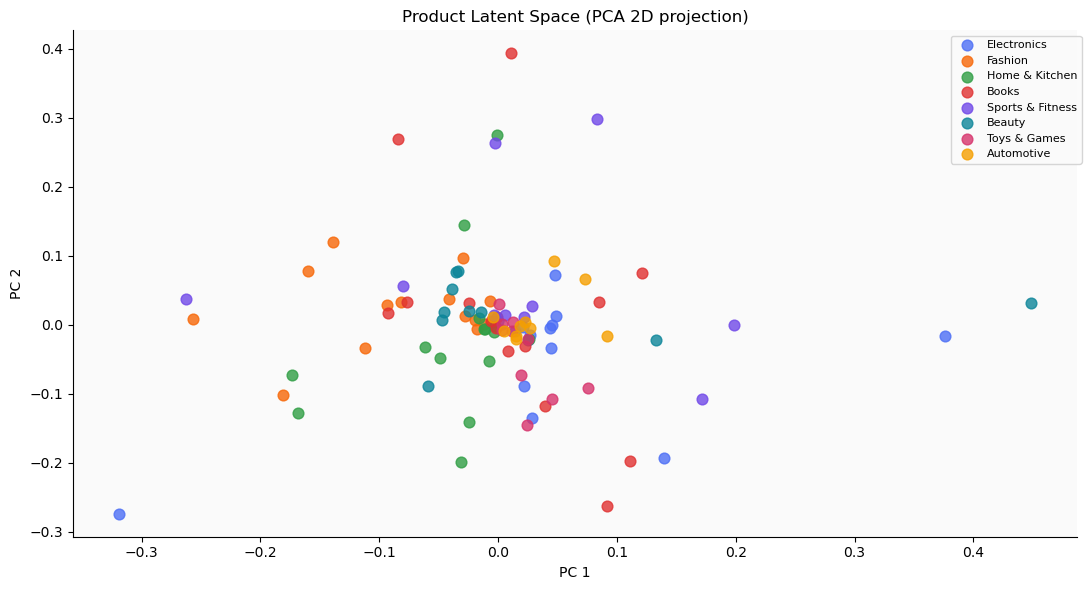

In [23]:
max_possible = min(train_matrix.shape[0]-1, train_matrix.shape[1]-1, CONFIG['svd_factors'])
N_FACTORS    = max(5, max_possible)
print(f'SVD factors: {N_FACTORS}')

svd_model    = TruncatedSVD(n_components=N_FACTORS, algorithm='randomized',
                             n_iter=10, random_state=CONFIG['random_seed'])
user_factors = svd_model.fit_transform(train_matrix)
item_factors = svd_model.components_.T
explained_v  = svd_model.explained_variance_ratio_

print(f'User factors : {user_factors.shape}')
print(f'Item factors : {item_factors.shape}')
print(f'Variance explained: {explained_v.sum()*100:.1f}% with {N_FACTORS} factors')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
top = min(25, N_FACTORS)
axes[0].bar(range(1, top + 1), explained_v[:top] * 100,
            color=PALETTE[0], edgecolor='white')
axes[0].set_title(f'Variance per Factor (top {top})')
axes[0].set_xlabel('Factor')
axes[0].set_ylabel('Explained variance (%)')

cum = np.cumsum(explained_v)
axes[1].plot(range(1, N_FACTORS + 1), cum * 100,
             color=PALETTE[1], linewidth=2, marker='o', markersize=3)
axes[1].axhline(80, color='#E03131', linestyle='--', linewidth=1, label='80% threshold')
axes[1].set_title('Cumulative Explained Variance')
axes[1].set_xlabel('Factors')
axes[1].set_ylabel('Cumulative (%)')
axes[1].legend()
plt.tight_layout()
plt.savefig('evaluation/svd_scree.png', dpi=150, bbox_inches='tight')
plt.show()

if N_FACTORS >= 2:
    pca_2d  = PCA(n_components=2, random_state=42)
    items2d = pca_2d.fit_transform(item_factors)
    cats    = products_df['category'].values
    uniq_c  = list(dict.fromkeys(cats))
    fig, ax = plt.subplots(figsize=(11, 6))
    for i, cat in enumerate(uniq_c):
        mask = cats == cat
        ax.scatter(items2d[mask, 0], items2d[mask, 1],
                   c=PALETTE[i % len(PALETTE)], label=cat, s=60, alpha=0.8)
    ax.legend(bbox_to_anchor=(1.01, 1), fontsize=8)
    ax.set_title('Product Latent Space (PCA 2D projection)')
    ax.set_xlabel('PC 1')
    ax.set_ylabel('PC 2')
    plt.tight_layout()
    plt.savefig('evaluation/svd_item_space.png', dpi=150, bbox_inches='tight')
    plt.show()


## 7. SVD++ — matrix factorization with implicit feedback

SVD++ extends standard matrix factorization with an implicit feedback term. For each user,
it adds the sum of latent item vectors for every product the user has interacted with,
allowing the model to leverage all historical behavior, not just explicit ratings.

Training SVD++...
  Epoch  10/30  loss=0.051997
  Epoch  20/30  loss=0.049328
  Epoch  30/30  loss=0.047767

SVD++ trained in 211.5s


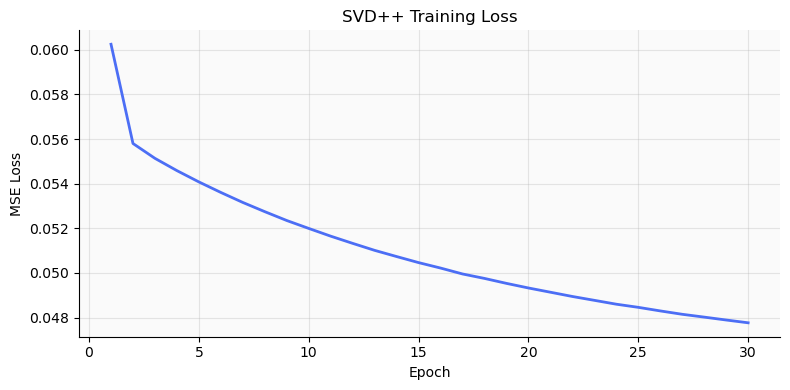

In [7]:
print('Training SVD++...')
t_start = time.time()

N_USERS    = len(ALL_USERS)
N_PRODUCTS = len(ALL_PRODUCTS)

K_PP   = min(CONFIG['svdpp_factors'], N_USERS - 1, N_PRODUCTS - 1)
N_E_PP = CONFIG['svdpp_epochs']
LR_PP  = CONFIG['svdpp_lr']
REG_PP = CONFIG['svdpp_reg']

_nonzero_mask = train_matrix > 0
MU_GLOBAL = float(train_matrix[_nonzero_mask].mean()) if _nonzero_mask.any() else 0.5

# Build implicit neighbourhood lookup: user index -> array of item indices
user_implicit_items = {}
for _u in range(N_USERS):
    _items = np.where(train_matrix[_u] > 0)[0]
    if len(_items):
        user_implicit_items[_u] = _items.astype(np.int32)

np.random.seed(CONFIG['random_seed'])
P_pp  = np.random.normal(0, 0.01, (N_USERS,    K_PP)).astype(np.float32)
Q_pp  = np.random.normal(0, 0.01, (N_PRODUCTS, K_PP)).astype(np.float32)
Y_pp  = np.random.normal(0, 0.01, (N_PRODUCTS, K_PP)).astype(np.float32)
bu_pp = np.zeros(N_USERS,    dtype=np.float32)
bi_pp = np.zeros(N_PRODUCTS, dtype=np.float32)

train_triples = [
    (ui, pi, sc)
    for ui in range(N_USERS)
    for pi, sc in enumerate(train_matrix[ui])
    if sc > 0
]

epoch_losses = []
for epoch in range(N_E_PP):
    np.random.shuffle(train_triples)
    epoch_loss = 0.0
    for u, i, r in train_triples:
        impl  = user_implicit_items.get(u, np.array([], dtype=np.int32))
        norm  = 1.0 / np.sqrt(max(len(impl), 1))
        y_sum = Y_pp[impl].sum(axis=0) * norm if len(impl) else np.zeros(K_PP, np.float32)
        pu    = P_pp[u] + y_sum
        pred  = float(np.clip(MU_GLOBAL + bu_pp[u] + bi_pp[i] + np.dot(pu, Q_pp[i]), 0.0, 1.0))
        err   = r - pred
        epoch_loss += err ** 2

        bu_pp[u] += LR_PP * (err - REG_PP * bu_pp[u])
        bi_pp[i] += LR_PP * (err - REG_PP * bi_pp[i])
        Q_pp[i]  += LR_PP * (err * pu - REG_PP * Q_pp[i])
        P_pp[u]  += LR_PP * (err * Q_pp[i] - REG_PP * P_pp[u])
        if len(impl):
            for k2 in impl:
                Y_pp[k2] += LR_PP * (err * norm * Q_pp[i] - REG_PP * Y_pp[k2])

    avg_loss = epoch_loss / max(len(train_triples), 1)
    epoch_losses.append(avg_loss)
    if (epoch + 1) % 10 == 0:
        print(f'  Epoch {epoch+1:3d}/{N_E_PP}  loss={avg_loss:.6f}')

elapsed_pp = time.time() - t_start
print(f'\nSVD++ trained in {elapsed_pp:.1f}s')

plt.figure(figsize=(8, 4))
plt.plot(range(1, N_E_PP + 1), epoch_losses, color=PALETTE[0], linewidth=2)
plt.title('SVD++ Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('evaluation/svdpp_loss.png', dpi=150, bbox_inches='tight')
plt.show()


def svdpp_predict(user_id, top_n=10):
    user_id = str(user_id)
    u = uid2idx.get(user_id)
    if u is None:
        return []
    impl   = user_implicit_items.get(u, np.array([], dtype=np.int32))
    norm   = 1.0 / np.sqrt(max(len(impl), 1))
    y_sum  = Y_pp[impl].sum(axis=0) * norm if len(impl) else np.zeros(K_PP, np.float32)
    pu     = P_pp[u] + y_sum
    scores = np.clip(MU_GLOBAL + bu_pp[u] + bi_pp + Q_pp.dot(pu), 0, 1)

    seen = user_seen_train.get(user_id, set())
    for pid in seen:
        j = pid2idx.get(pid)
        if j is not None:
            scores[j] = -1.0

    top_idx = np.argsort(scores)[::-1][:top_n]
    return [str(ALL_PRODUCTS[j]) for j in top_idx if scores[j] >= 0]


## 8. LightFM-style hybrid BPR model

Bayesian Personalised Ranking (BPR) trains the model to score observed interactions
higher than unobserved ones. We augment user embeddings with persona features and item
embeddings with TF-IDF text features, making this model particularly effective for
cold-start situations.

Training LightFM BPR hybrid...
  TF-IDF item feature matrix: (100, 300)
  User persona feature matrix: (9699, 9)
  Epoch  10/30  loss=0.5405
  Epoch  20/30  loss=0.5208
  Epoch  30/30  loss=0.4962

LightFM trained in 57.6s


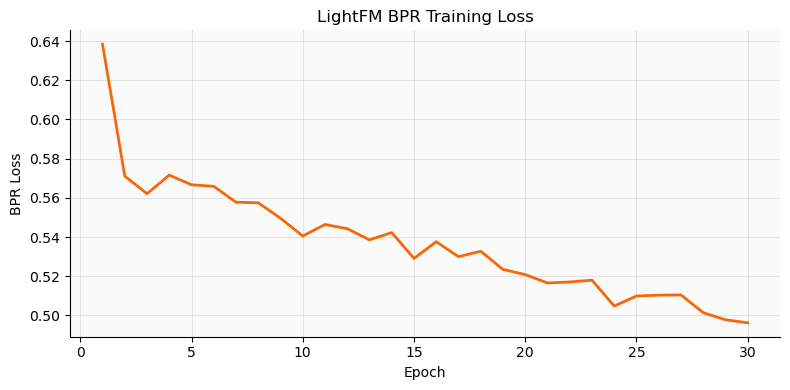

In [8]:
print('Training LightFM BPR hybrid...')
t_start = time.time()

def parse_tags(tag_str):
    if pd.isna(tag_str):
        return ''
    return ' '.join(re.findall(r"'([^']+)'", str(tag_str)))

products_df['tags_clean']   = products_df['tags'].apply(parse_tags)
products_df['text_feature'] = (
    products_df['name'].fillna('')     + ' ' +
    products_df['category'].fillna('') + ' ' +
    products_df['tags_clean']
)

tfidf_vec    = TfidfVectorizer(max_features=300, stop_words='english',
                                ngram_range=(1, 2), sublinear_tf=True)
item_text_mat = tfidf_vec.fit_transform(products_df['text_feature']).toarray().astype(np.float32)
N_TEXT_FEAT   = item_text_mat.shape[1]
print(f'  TF-IDF item feature matrix: {item_text_mat.shape}')

le_persona    = LabelEncoder()
le_persona.fit(users_df['persona'].fillna('unknown'))
N_PERSONA     = len(le_persona.classes_)
user_feat_mat = np.zeros((N_USERS, N_PERSONA), dtype=np.float32)
for _uid_str in ALL_USERS:
    _row = users_df[users_df['userId'] == _uid_str]
    if len(_row):
        _code = le_persona.transform([_row['persona'].values[0]])[0]
        user_feat_mat[uid2idx[_uid_str], _code] = 1.0
print(f'  User persona feature matrix: {user_feat_mat.shape}')

LF = CONFIG['lfm_factors']
np.random.seed(CONFIG['random_seed'])
Pu_fm = np.random.normal(0, 0.01, (N_USERS,     LF)).astype(np.float32)
Qi_fm = np.random.normal(0, 0.01, (N_PRODUCTS,  LF)).astype(np.float32)
Au_fm = np.random.normal(0, 0.01, (N_PERSONA,   LF)).astype(np.float32)
Bi_fm = np.random.normal(0, 0.01, (N_TEXT_FEAT, LF)).astype(np.float32)

def _fm_user_vec(u):
    uf = user_feat_mat[u]
    nz = uf.nonzero()[0]
    return Pu_fm[u] + (Au_fm[nz].sum(axis=0) if len(nz) else 0)

def _fm_item_vec(i):
    itf = item_text_mat[i]
    nz  = itf.nonzero()[0]
    return Qi_fm[i] + (Bi_fm[nz] * itf[nz, None]).sum(axis=0) if len(nz) else Qi_fm[i]

pos_pairs  = [(u, j) for u in range(N_USERS) for j in np.where(train_matrix[u] > 0)[0]]
LR_FM      = CONFIG['lfm_lr']
REG_FM     = CONFIG['lfm_reg']
bpr_losses = []

for epoch in range(CONFIG['lfm_epochs']):
    np.random.shuffle(pos_pairs)
    sampled    = pos_pairs[:CONFIG['lfm_pairs']]
    epoch_loss = 0.0
    for u, i in sampled:
        j = np.random.randint(N_PRODUCTS)
        while train_matrix[u, j] > 0:
            j = np.random.randint(N_PRODUCTS)
        pu   = _fm_user_vec(u)
        qi   = _fm_item_vec(i)
        qj   = _fm_item_vec(j)
        diff = float(np.dot(pu, qi - qj))
        sig  = 1.0 / (1.0 + np.exp(-diff))
        grad = 1.0 - sig
        epoch_loss += -np.log(sig + 1e-10)
        dpu = grad * (qi - qj) - REG_FM * pu
        dqi = grad * pu - REG_FM * qi
        dqj = -grad * pu - REG_FM * qj
        Pu_fm[u] += LR_FM * dpu
        Qi_fm[i] += LR_FM * dqi
        Qi_fm[j] += LR_FM * dqj
        for nz in user_feat_mat[u].nonzero()[0]:
            Au_fm[nz] += LR_FM * dpu
        for nz_item, dq in [(i, LR_FM * dqi), (j, LR_FM * dqj)]:
            nz_f = item_text_mat[nz_item].nonzero()[0]
            for k in nz_f:
                Bi_fm[k] += dq * item_text_mat[nz_item][k]
    n = max(len(sampled), 1)
    bpr_losses.append(epoch_loss / n)
    if (epoch + 1) % 10 == 0:
        print(f'  Epoch {epoch+1:3d}/{CONFIG["lfm_epochs"]}  loss={epoch_loss/n:.4f}')

elapsed_fm = time.time() - t_start
print(f'\nLightFM trained in {elapsed_fm:.1f}s')

plt.figure(figsize=(8, 4))
plt.plot(range(1, CONFIG['lfm_epochs'] + 1), bpr_losses, color=PALETTE[1], linewidth=2)
plt.title('LightFM BPR Training Loss')
plt.xlabel('Epoch')
plt.ylabel('BPR Loss')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('evaluation/lfm_loss.png', dpi=150, bbox_inches='tight')
plt.show()


def lightfm_predict(user_id, top_n=10):
    user_id = str(user_id)
    u = uid2idx.get(user_id)
    if u is None:
        return []
    pu     = _fm_user_vec(u)
    scores = np.array([float(np.dot(pu, _fm_item_vec(j))) for j in range(N_PRODUCTS)],
                      dtype=np.float32)
    seen = user_seen_train.get(user_id, set())
    for pid in seen:
        j = pid2idx.get(pid)
        if j is not None:
            scores[j] = -np.inf
    top_idx = np.argsort(scores)[::-1][:top_n]
    return [str(ALL_PRODUCTS[j]) for j in top_idx if np.isfinite(scores[j])]


## 9. KNN collaborative filtering (user-based and item-based)

In [24]:
K_user = min(CONFIG['knn_k'], len(ALL_USERS) - 1)
K_item = min(CONFIG['knn_k'], len(ALL_PRODUCTS) - 1)

knn_user = NearestNeighbors(n_neighbors=K_user + 1, metric='cosine',
                             algorithm='brute', n_jobs=-1)
knn_user.fit(user_factors)
print(f'User-based KNN fitted  (K={K_user}, n_users={len(ALL_USERS):,})')

knn_item = NearestNeighbors(n_neighbors=K_item + 1, metric='cosine',
                             algorithm='brute', n_jobs=-1)
knn_item.fit(item_factors)
print(f'Item-based KNN fitted  (K={K_item}, n_products={len(ALL_PRODUCTS)})')


def user_based_cf_scores(user_idx):
    vec           = user_factors[user_idx].reshape(1, -1)
    dists, nb_idx = knn_user.kneighbors(vec)
    dists, nb_idx = dists[0], nb_idx[0]
    mask          = nb_idx != user_idx
    dists, nb_idx = dists[mask], nb_idx[mask]
    sims          = np.clip(1 - dists, 0, 1)
    scores        = np.dot(sims, train_matrix[nb_idx])
    return scores / (sims.sum() + 1e-9)


def item_based_cf_scores(user_idx):
    user_row  = train_matrix[user_idx]
    pos_items = np.where(user_row > 0)[0]
    if not len(pos_items):
        return np.zeros(len(ALL_PRODUCTS), dtype=np.float32)
    scores = np.zeros(len(ALL_PRODUCTS), dtype=np.float32)
    for item_idx in pos_items:
        vec = item_factors[item_idx].reshape(1, -1)
        dists, nb_idx = knn_item.kneighbors(vec)
        dists, nb_idx = dists[0][1:], nb_idx[0][1:]
        sims = np.clip(1 - dists, 0, 1)
        scores[nb_idx] += sims * user_row[item_idx]
    return scores


# Demo: nearest neighbours for the first user
demo_uid  = ALL_USERS[0]
demo_idx  = uid2idx[demo_uid]
demo_row  = users_df[users_df['userId'] == demo_uid].iloc[0]
print(f'\n5 most similar users to [{demo_uid}] ({demo_row["persona"]}):')
vec        = user_factors[demo_idx].reshape(1, -1)
dists, nbs = knn_user.kneighbors(vec)
for d, nb in zip(dists[0][1:6], nbs[0][1:6]):
    nb_uid = ALL_USERS[nb]
    nb_row = users_df[users_df['userId'] == nb_uid]
    if len(nb_row):
        print(f'  {nb_uid}  sim={1-d:.3f}  persona={nb_row["persona"].values[0]}')


User-based KNN fitted  (K=20, n_users=9,699)
Item-based KNN fitted  (K=20, n_products=100)

5 most similar users to [user_00001] (bookworm):
  user_07383  sim=0.782  persona=bookworm
  user_00634  sim=0.740  persona=parent
  user_03512  sim=0.730  persona=home_chef
  user_02759  sim=0.728  persona=bookworm
  user_08534  sim=0.725  persona=home_chef


## 10. Content-based filtering and popularity scoring

In [10]:
# Build TF-IDF content similarity matrix
tfidf_matrix  = tfidf_vec.transform(products_df['text_feature'])
content_sim   = cosine_similarity(tfidf_matrix, tfidf_matrix)
tfidf_pids    = products_df['productId'].tolist()
tfidf_pid2idx = {p: i for i, p in enumerate(tfidf_pids)}

print(f'TF-IDF matrix      : {tfidf_matrix.shape}')
print(f'Content sim matrix : {content_sim.shape}')

# Popularity = avgRating * log(1 + numReviews), normalised to [0, 1]
rv_ = products_df['avgRating'].fillna(3.0).values.reshape(-1, 1)
nv_ = np.log1p(products_df['numReviews'].fillna(0).values.reshape(-1, 1))
pp_ = rv_ * nv_
products_df['pop_score'] = (pp_ / (pp_.max() + 1e-9)).flatten()
popularity_scores = dict(zip(products_df['productId'], products_df['pop_score']))

print('\nTop 5 most popular products:')
top_pop = sorted(popularity_scores.items(), key=lambda x: x[1], reverse=True)[:5]
for pid, sc in top_pop:
    row = products_df[products_df['productId'] == pid].iloc[0]
    print(f'  {pid}  pop={sc:.4f}  {row["category"]:18s}  {row["name"][:35]}')


def content_based_scores(interacted_pids, exclude=None):
    exclude   = exclude or set()
    score_agg = np.zeros(len(tfidf_pids), dtype=np.float32)
    for pid in interacted_pids:
        i = tfidf_pid2idx.get(pid)
        if i is not None:
            score_agg += content_sim[i]
    for pid in exclude:
        j = tfidf_pid2idx.get(pid)
        if j is not None:
            score_agg[j] = 0.0
    return {tfidf_pids[j]: float(score_agg[j]) for j in range(len(tfidf_pids))}


TF-IDF matrix      : (100, 300)
Content sim matrix : (100, 100)

Top 5 most popular products:
  prod_0045  pop=1.0000  Home & Kitchen      Mixing Bowl Set
  prod_0016  pop=0.9971  Fashion             Slim-Fit Jeans
  prod_0020  pop=0.9539  Fashion             Formal Shirt
  prod_0062  pop=0.9391  Sports & Fitness    Resistance Bands (set)
  prod_0022  pop=0.9379  Fashion             Ankle Boots


## 11. Hybrid ensemble

Adaptive weights blend all four signals based on how many interactions a user has.
New users (cold start) rely on content and popularity. Active users benefit most
from collaborative filtering signals.

In [11]:
def get_weights(n_interactions):
    if n_interactions < 3:
        return {'user_cf': 0.05, 'item_cf': 0.05, 'content': 0.30, 'popularity': 0.60}
    elif n_interactions < 10:
        return {'user_cf': 0.25, 'item_cf': 0.25, 'content': 0.30, 'popularity': 0.20}
    else:
        return {'user_cf': 0.40, 'item_cf': 0.35, 'content': 0.20, 'popularity': 0.05}


def recommend(user_id, top_n=None, weights=None, _seen_override=None):
    """
    Generate top-N product recommendations for a given user.

    Parameters
    ----------
    user_id        : str   - matches userId in users.csv (e.g. 'user_00001')
    top_n          : int   - number of recommendations (default CONFIG['top_n'])
    weights        : dict  - override adaptive signal weights
    _seen_override : set   - products already seen (use train-only set during evaluation
                             to avoid leakage; omit for production recommendations)

    Returns
    -------
    list of dicts with keys: productId, name, category, price, avgRating, score,
                             reason, coldStart
    """
    if top_n is None:
        top_n = CONFIG['top_n']

    user_id  = str(user_id)
    user_idx = uid2idx.get(user_id)

    seen    = set(str(p) for p in (_seen_override if _seen_override is not None
                                   else user_seen.get(user_id, set())))
    is_cold = len(seen) < 3
    w       = weights or get_weights(len(seen))
    scores  = defaultdict(float)
    reason  = {}

    if user_idx is not None and w['user_cf'] > 0:
        ucf   = user_based_cf_scores(user_idx)
        max_s = ucf.max() + 1e-9
        for j, s in enumerate(ucf):
            if s > 0:
                p = str(ALL_PRODUCTS[j])
                scores[p] += w['user_cf'] * (s / max_s)
                reason.setdefault(p, 'user_cf')

    if user_idx is not None and w['item_cf'] > 0:
        icf   = item_based_cf_scores(user_idx)
        max_s = icf.max() + 1e-9
        for j, s in enumerate(icf):
            if s > 0:
                p = str(ALL_PRODUCTS[j])
                scores[p] += w['item_cf'] * (s / max_s)
                reason.setdefault(p, 'item_cf')

    if w['content'] > 0 and len(seen) > 0:
        cb    = content_based_scores(list(seen)[:30])
        max_s = max(cb.values()) + 1e-9 if cb else 1
        for p, s in cb.items():
            p = str(p)
            scores[p] += w['content'] * (s / max_s)
            reason.setdefault(p, 'content')

    if w['popularity'] > 0:
        for p, s in popularity_scores.items():
            p = str(p)
            if p not in seen:
                scores[p] += w['popularity'] * s
                reason.setdefault(p, 'popularity')

    for p in seen:
        scores.pop(str(p), None)

    ranked  = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:top_n]
    results = []
    for p, sc in ranked:
        row = products_df[products_df['productId'].astype(str) == p]
        results.append({
            'productId': p,
            'name':      row['name'].values[0]             if len(row) else p,
            'category':  row['category'].values[0]         if len(row) else 'Unknown',
            'price':     float(row['price'].values[0])     if len(row) else 0.0,
            'avgRating': float(row['avgRating'].values[0]) if len(row) else 0.0,
            'score':     round(float(sc), 5),
            'reason':    reason.get(p, 'mixed'),
            'coldStart': is_cold,
        })
    return results


# Quick demo
sample_user = ALL_USERS[0]
print(f'Sample recommendations for {sample_user}:')
recs = recommend(sample_user, top_n=5)
for r in recs:
    print(f'  {r["productId"]}  score={r["score"]:.4f}  [{r["reason"]}]  {r["name"][:35]}')


Sample recommendations for user_00001:
  prod_0048  score=0.6852  [user_cf]  The Pragmatic Programmer
  prod_0054  score=0.5585  [user_cf]  The Psychology of Money
  prod_0060  score=0.4835  [user_cf]  The Lean Startup
  prod_0100  score=0.4352  [item_cf]  LED Interior Lights
  prod_0044  score=0.4246  [user_cf]  Tea Kettle


## 12. Ranking evaluation (Precision@K, Recall@K, NDCG@K)


EVALUATION  K=10  Users=200
  precision@10        : 0.0535
  recall@10           : 0.19334
  f1@10               : 0.07696
  ndcg@10             : 0.11856
  diversity           : 0.88198
  catalog_coverage    : 0.91
  n_test_users        : 200

Ablation study — single-signal baselines:
  User-CF only              P@10=0.0320  R@10=0.0903  NDCG@10=0.0638
  Item-CF only              P@10=0.0420  R@10=0.1530  NDCG@10=0.0943
  Content-based             P@10=0.0560  R@10=0.2373  NDCG@10=0.1396
  Popularity                P@10=0.0340  R@10=0.1193  NDCG@10=0.0741
  Hybrid                    P@10=0.0470  R@10=0.1573  NDCG@10=0.1093


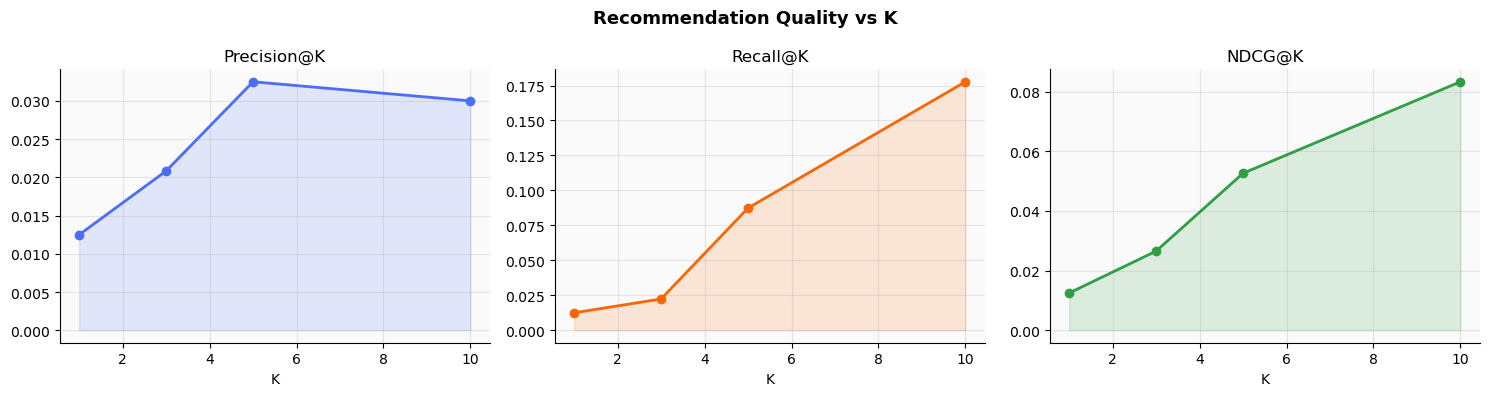

Chart saved.


In [12]:
def precision_at_k(recommended, relevant, k):
    if k == 0:
        return 0.0
    rec = [str(p) for p in recommended[:k]]
    rel = set(str(p) for p in relevant)
    return len(set(rec) & rel) / k


def recall_at_k(recommended, relevant, k):
    rel = set(str(p) for p in relevant)
    if not rel:
        return 0.0
    rec = [str(p) for p in recommended[:k]]
    return len(set(rec) & rel) / len(rel)


def ndcg_at_k(recommended, relevant, k):
    rel  = set(str(p) for p in relevant)
    rec  = [str(p) for p in recommended[:k]]
    dcg  = sum(1.0 / np.log2(i + 2) for i, p in enumerate(rec) if p in rel)
    idcg = sum(1.0 / np.log2(i + 2) for i in range(min(len(rel), k)))
    return dcg / idcg if idcg > 0 else 0.0


def avg_diversity(recs):
    pids = [str(r['productId']) for r in recs]
    idx  = [tfidf_pid2idx[p] for p in pids if p in tfidf_pid2idx]
    if len(idx) < 2:
        return 0.0
    total, count = 0.0, 0
    for i in range(len(idx)):
        for j in range(i + 1, len(idx)):
            total += content_sim[idx[i], idx[j]]
            count += 1
    return 1.0 - (total / count if count else 0.0)


def evaluate(gt, k=10, n_samples=200, verbose=True):
    import random
    random.seed(CONFIG['random_seed'])
    users = list(gt.keys())
    if len(users) > n_samples:
        users = random.sample(users, n_samples)

    P, R, F, N, D = [], [], [], [], []
    all_recs = set()

    for uid in users:
        rel        = gt[uid]
        train_seen = user_seen_train.get(str(uid), set())
        recs       = recommend(uid, top_n=k, _seen_override=train_seen)
        pids       = [str(r['productId']) for r in recs]
        all_recs.update(pids)
        p = precision_at_k(pids, rel, k)
        r = recall_at_k(pids, rel, k)
        f = 2 * p * r / (p + r) if (p + r) else 0
        n = ndcg_at_k(pids, rel, k)
        d = avg_diversity(recs)
        P.append(p); R.append(r); F.append(f); N.append(n); D.append(d)

    coverage = len(all_recs) / len(ALL_PRODUCTS)
    metrics  = {
        f'precision@{k}':  round(float(np.mean(P)), 5),
        f'recall@{k}':     round(float(np.mean(R)), 5),
        f'f1@{k}':         round(float(np.mean(F)), 5),
        f'ndcg@{k}':       round(float(np.mean(N)), 5),
        'diversity':        round(float(np.mean(D)), 5),
        'catalog_coverage': round(coverage, 5),
        'n_test_users':     len(users),
    }
    if verbose:
        print(f'\nEVALUATION  K={k}  Users={len(users)}')
        print('=' * 50)
        for key, val in metrics.items():
            print(f'  {key:<20}: {val}')
        print('=' * 50)
    return metrics


eval_metrics = evaluate(test_gt_eval, k=CONFIG['top_n'], n_samples=200)

# Ablation study
print('\nAblation study — single-signal baselines:')


def eval_single(weights, label, n=100):
    import random
    random.seed(42)
    users = list(test_gt_eval.keys())
    if len(users) > n:
        users = random.sample(users, n)
    P, R, N = [], [], []
    for uid in users:
        rel        = test_gt_eval[uid]
        train_seen = user_seen_train.get(str(uid), set())
        recs       = recommend(uid, top_n=CONFIG['top_n'], weights=weights,
                               _seen_override=train_seen)
        pids       = [str(r['productId']) for r in recs]
        P.append(precision_at_k(pids, rel, CONFIG['top_n']))
        R.append(recall_at_k(pids, rel, CONFIG['top_n']))
        N.append(ndcg_at_k(pids, rel, CONFIG['top_n']))
    k = CONFIG['top_n']
    print(f'  {label:<25} P@{k}={np.mean(P):.4f}  R@{k}={np.mean(R):.4f}  NDCG@{k}={np.mean(N):.4f}')


eval_single({'user_cf': 1,    'item_cf': 0,    'content': 0,    'popularity': 0   }, 'User-CF only')
eval_single({'user_cf': 0,    'item_cf': 1,    'content': 0,    'popularity': 0   }, 'Item-CF only')
eval_single({'user_cf': 0,    'item_cf': 0,    'content': 1,    'popularity': 0   }, 'Content-based')
eval_single({'user_cf': 0,    'item_cf': 0,    'content': 0,    'popularity': 1   }, 'Popularity')
eval_single({'user_cf': 0.40, 'item_cf': 0.35, 'content': 0.20, 'popularity': 0.05}, 'Hybrid')

# Metrics vs K plot
K_VALUES     = [1, 3, 5, 10]
sample_users = list(test_gt_eval.keys())[:80]
P_v, R_v, N_v = [], [], []
for k in K_VALUES:
    Pk, Rk, Nk = [], [], []
    for uid in sample_users:
        rel        = test_gt_eval[uid]
        train_seen = user_seen_train.get(str(uid), set())
        recs       = recommend(uid, top_n=max(K_VALUES), _seen_override=train_seen)
        pids       = [str(r['productId']) for r in recs]
        Pk.append(precision_at_k(pids, rel, k))
        Rk.append(recall_at_k(pids, rel, k))
        Nk.append(ndcg_at_k(pids, rel, k))
    P_v.append(np.mean(Pk))
    R_v.append(np.mean(Rk))
    N_v.append(np.mean(Nk))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
metrics_data = [
    (P_v, 'Precision@K', PALETTE[0]),
    (R_v, 'Recall@K',    PALETTE[1]),
    (N_v, 'NDCG@K',      PALETTE[2]),
]
for ax, (vals, title, color) in zip(axes, metrics_data):
    ax.plot(K_VALUES, vals, marker='o', color=color, linewidth=2)
    ax.fill_between(K_VALUES, vals, alpha=0.15, color=color)
    ax.set_title(title)
    ax.set_xlabel('K')
    ax.grid(alpha=0.3)
plt.suptitle('Recommendation Quality vs K', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('evaluation/metrics_vs_k.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved.')


## 13. Model comparison (Hybrid vs SVD++ vs LightFM)

Evaluating 3 models  (K=10, n_samples=300)

  KNN+SVD (Hybrid)        P@10=0.05400  R@10=0.17432  NDCG@10=0.11292  hits=119/300
  SVD++                   P@10=0.02533  R@10=0.10508  NDCG@10=0.06168  hits=71/300
  LightFM-BPR             P@10=0.07900  R@10=0.29643  NDCG@10=0.17008  hits=169/300

Best model by NDCG@10: LightFM-BPR

Full results:
           model  precision@10  recall@10  ndcg@10  diversity  catalog_coverage  train_time_s
KNN+SVD (Hybrid)        0.0540     0.1743   0.1129     0.8817            0.9400        0.0000
           SVD++        0.0253     0.1051   0.0617     0.9660            0.1500      211.5000
     LightFM-BPR        0.0790     0.2964   0.1701     0.8514            0.9400       57.6000


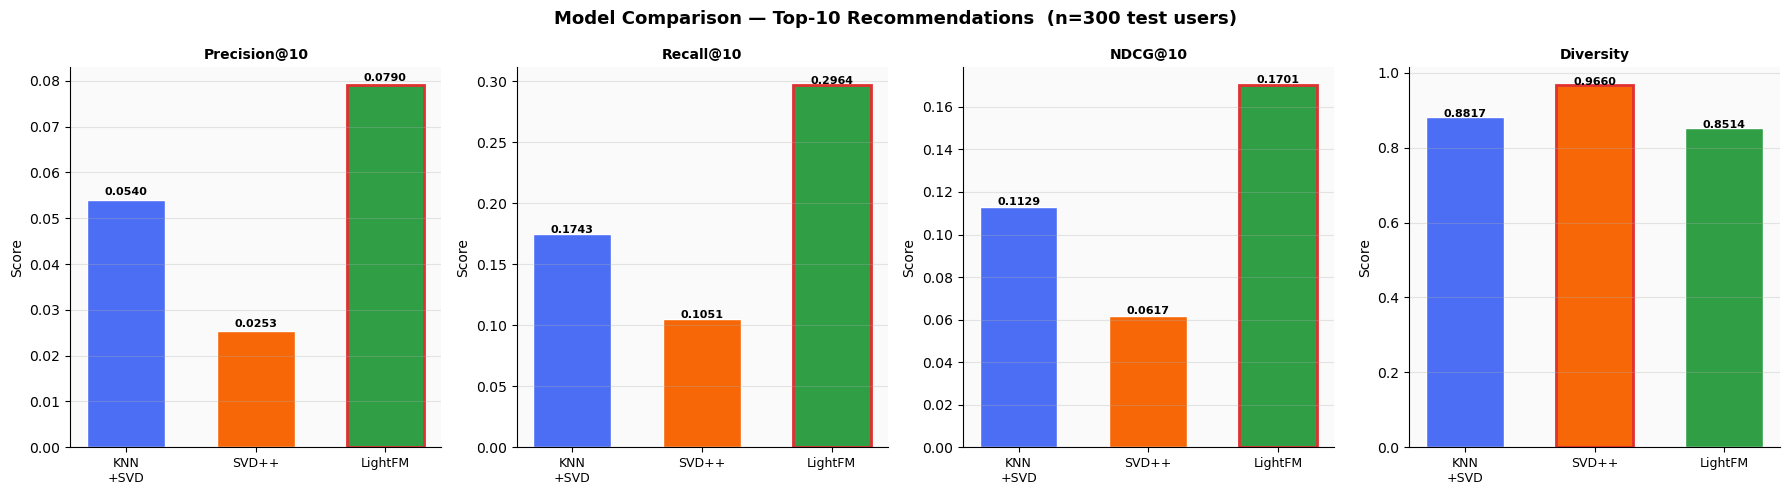

Saved model_comparison.png


In [13]:
def _precision_at_k(recommended, relevant, k):
    if k == 0: return 0.0
    rec = [str(p) for p in recommended[:k]]
    rel = set(str(p) for p in relevant)
    return len(set(rec) & rel) / k

def _recall_at_k(recommended, relevant, k):
    rel = set(str(p) for p in relevant)
    if not rel: return 0.0
    rec = [str(p) for p in recommended[:k]]
    return len(set(rec) & rel) / len(rel)

def _ndcg_at_k(recommended, relevant, k):
    rel  = set(str(p) for p in relevant)
    rec  = [str(p) for p in recommended[:k]]
    dcg  = sum(1.0 / np.log2(i + 2) for i, p in enumerate(rec) if p in rel)
    idcg = sum(1.0 / np.log2(i + 2) for i in range(min(len(rel), k)))
    return dcg / idcg if idcg > 0 else 0.0

def _avg_diversity(pids):
    idx = [tfidf_pid2idx[str(p)] for p in pids if str(p) in tfidf_pid2idx]
    if len(idx) < 2: return 0.0
    total = sum(content_sim[idx[a], idx[b]]
                for a in range(len(idx)) for b in range(a + 1, len(idx)))
    count = len(idx) * (len(idx) - 1) // 2
    return 1.0 - (total / count)


def _evaluate_model(predict_fn, gt, k, n_samples, label, returns_dicts=False):
    import random
    random.seed(CONFIG['random_seed'])
    users = list(gt.keys())
    if len(users) > n_samples:
        users = random.sample(users, n_samples)

    P, R, N, D = [], [], [], []
    all_recs    = set()

    for uid in users:
        rel        = gt[uid]
        train_seen = user_seen_train.get(str(uid), set())
        if returns_dicts:
            raw  = predict_fn(uid, top_n=k, _seen_override=train_seen)
            pids = [str(r['productId']) for r in raw]
        else:
            pids = [str(p) for p in predict_fn(uid, top_n=k)]
        all_recs.update(pids)
        P.append(_precision_at_k(pids, rel, k))
        R.append(_recall_at_k(pids, rel, k))
        N.append(_ndcg_at_k(pids, rel, k))
        D.append(_avg_diversity(pids))

    cov = len(all_recs) / len(ALL_PRODUCTS)
    return {
        'model':            label,
        f'precision@{k}':  round(float(np.mean(P)), 5),
        f'recall@{k}':     round(float(np.mean(R)), 5),
        f'ndcg@{k}':       round(float(np.mean(N)), 5),
        'diversity':        round(float(np.mean(D)), 5),
        'catalog_coverage': round(float(cov),        5),
        'hits':             int(sum(p > 0 for p in P)),
        'n_users':          len(users),
    }


K_EVAL, N_EVAL = CONFIG['top_n'], 300

_model_registry = [
    ('KNN+SVD (Hybrid)', recommend,       True),
    ('SVD++',            svdpp_predict,   False),
    ('LightFM-BPR',      lightfm_predict, False),
]

_train_times = {
    'KNN+SVD (Hybrid)': 0.0,
    'SVD++':            elapsed_pp,
    'LightFM-BPR':      elapsed_fm,
}

print(f'Evaluating {len(_model_registry)} models  (K={K_EVAL}, n_samples={N_EVAL})\n')
results_list = []
for label, fn, is_dict in _model_registry:
    res = _evaluate_model(fn, test_gt_eval, k=K_EVAL, n_samples=N_EVAL,
                          label=label, returns_dicts=is_dict)
    res['train_time_s'] = round(_train_times.get(label, 0.0), 1)
    results_list.append(res)
    print(f'  {label:<22}  P@{K_EVAL}={res[f"precision@{K_EVAL}"]:.5f}  '
          f'R@{K_EVAL}={res[f"recall@{K_EVAL}"]:.5f}  '
          f'NDCG@{K_EVAL}={res[f"ndcg@{K_EVAL}"]:.5f}  '
          f'hits={res["hits"]}/{res["n_users"]}')

results_df = pd.DataFrame(results_list)
best_model = results_df.loc[results_df[f'ndcg@{K_EVAL}'].idxmax(), 'model']
print(f'\nBest model by NDCG@{K_EVAL}: {best_model}')

display_cols = ['model', f'precision@{K_EVAL}', f'recall@{K_EVAL}',
                f'ndcg@{K_EVAL}', 'diversity', 'catalog_coverage', 'train_time_s']
print('\nFull results:')
print(results_df[display_cols].to_string(index=False))

_metric_pairs = [
    (f'precision@{K_EVAL}', f'Precision@{K_EVAL}'),
    (f'recall@{K_EVAL}',    f'Recall@{K_EVAL}'),
    (f'ndcg@{K_EVAL}',      f'NDCG@{K_EVAL}'),
    ('diversity',            'Diversity'),
]
_short_labels = ['KNN\n+SVD', 'SVD++', 'LightFM']
_colors = PALETTE[:3]

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, (metric, title) in zip(axes, _metric_pairs):
    vals = results_df[metric].tolist()
    bars = ax.bar(range(len(_model_registry)), vals, color=_colors,
                  edgecolor='white', width=0.6)
    ax.set_xticks(range(len(_model_registry)))
    ax.set_xticklabels(_short_labels, fontsize=9)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_ylabel('Score')
    ax.grid(axis='y', alpha=0.3)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.001,
                f'{v:.4f}', ha='center', fontsize=8, fontweight='bold')
    bars[int(np.argmax(vals))].set_edgecolor('#E03131')
    bars[int(np.argmax(vals))].set_linewidth(2)

fig.suptitle(f'Model Comparison — Top-{K_EVAL} Recommendations  (n={N_EVAL} test users)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('evaluation/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved model_comparison.png')


## 14. Confusion matrix and classification metrics

For each sampled user we create binary vectors over all 100 products.
A product is labelled relevant (y=1) if it appears in the user's test ground truth,
and predicted positive (y_hat=1) if the model includes it in its top-N list.

In [14]:
def build_binary_labels(gt, recommend_fn, top_n, n_samples=200, seed=42):
    import random
    random.seed(seed)
    users = list(gt.keys())
    if len(users) > n_samples:
        users = random.sample(users, n_samples)

    all_true, all_pred, all_scores = [], [], []
    all_products_list = [str(p) for p in ALL_PRODUCTS]

    for uid in users:
        rel        = gt[uid]
        train_seen = user_seen_train.get(str(uid), set())
        recs       = recommend_fn(uid, top_n=top_n, _seen_override=train_seen)
        score_dict = {str(r['productId']): r['score'] for r in recs}
        rec_set    = set(score_dict.keys())
        for p in all_products_list:
            all_true.append(1 if p in rel else 0)
            all_pred.append(1 if p in rec_set else 0)
            all_scores.append(score_dict.get(p, 0.0))

    return np.array(all_true), np.array(all_pred), np.array(all_scores), users


print('Building binary labels for the hybrid model...')
y_true, y_pred, y_scores, eval_users = build_binary_labels(
    test_gt_eval, recommend, top_n=CONFIG['top_n'], n_samples=200
)
print(f'Data points : {len(y_true):,}')
print(f'  Positive (relevant): {y_true.sum():,}  ({y_true.mean()*100:.2f}%)')
print(f'  Predicted positive : {y_pred.sum():,}  ({y_pred.mean()*100:.2f}%)')
print(f'  True positives     : {((y_true==1) & (y_pred==1)).sum():,}')

cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()

accuracy    = accuracy_score(y_true, y_pred)
precision   = precision_score(y_true, y_pred, zero_division=0)
recall      = recall_score(y_true, y_pred, zero_division=0)
f1          = f1_score(y_true, y_pred, zero_division=0)
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
fpr_val     = fp / (fp + tn) if (fp + tn) > 0 else 0
fnr_val     = fn / (fn + tp) if (fn + tp) > 0 else 0
try:
    roc_auc  = roc_auc_score(y_true, y_scores)
    avg_prec = average_precision_score(y_true, y_scores)
except Exception:
    roc_auc  = float('nan')
    avg_prec = float('nan')

print('\n' + '=' * 55)
print('CLASSIFICATION METRICS - HYBRID MODEL')
print('=' * 55)
print(f'  Accuracy          : {accuracy:.5f}')
print(f'  Precision         : {precision:.5f}')
print(f'  Recall (TPR)      : {recall:.5f}')
print(f'  F1 Score          : {f1:.5f}')
print(f'  Specificity (TNR) : {specificity:.5f}')
print(f'  False Positive Rate: {fpr_val:.5f}')
print(f'  False Negative Rate: {fnr_val:.5f}')
print(f'  ROC-AUC           : {roc_auc:.5f}')
print(f'  Avg Precision (AP): {avg_prec:.5f}')
print('-' * 55)
print(f'  TP={tp:,}  FP={fp:,}  FN={fn:,}  TN={tn:,}')
print('=' * 55)

print('\nFull Classification Report:')
print(classification_report(y_true, y_pred,
                             target_names=['Not Relevant', 'Relevant'],
                             zero_division=0))

# Per-model ablation
ABLATION_CONFIGS = [
    ({'user_cf': 1,    'item_cf': 0,    'content': 0,    'popularity': 0   }, 'User-CF'),
    ({'user_cf': 0,    'item_cf': 1,    'content': 0,    'popularity': 0   }, 'Item-CF'),
    ({'user_cf': 0,    'item_cf': 0,    'content': 1,    'popularity': 0   }, 'Content'),
    ({'user_cf': 0,    'item_cf': 0,    'content': 0,    'popularity': 1   }, 'Popularity'),
    ({'user_cf': 0.40, 'item_cf': 0.35, 'content': 0.20, 'popularity': 0.05}, 'Hybrid'),
]

ablation_results = []
print('\nBuilding per-model binary labels...')
for w, label in ABLATION_CONFIGS:
    def rec_fn(uid, top_n, _seen_override, _w=w):
        return recommend(uid, top_n=top_n, weights=_w, _seen_override=_seen_override)
    yt, yp, ys, _ = build_binary_labels(
        test_gt_eval, rec_fn, top_n=CONFIG['top_n'], n_samples=150
    )
    cm_i = confusion_matrix(yt, yp)
    tn_i, fp_i, fn_i, tp_i = cm_i.ravel()
    ablation_results.append({
        'label':       label,
        'accuracy':    accuracy_score(yt, yp),
        'precision':   precision_score(yt, yp, zero_division=0),
        'recall':      recall_score(yt, yp, zero_division=0),
        'f1':          f1_score(yt, yp, zero_division=0),
        'specificity': tn_i / (tn_i + fp_i + 1e-9),
        'roc_auc':     roc_auc_score(yt, ys) if yt.sum() > 0 else 0,
        'tp': tp_i, 'fp': fp_i, 'fn': fn_i, 'tn': tn_i, 'cm': cm_i,
    })
    print(f'  {label} done')


Building binary labels for the hybrid model...
Data points : 20,000
  Positive (relevant): 566  (2.83%)
  Predicted positive : 2,000  (10.00%)
  True positives     : 107

CLASSIFICATION METRICS - HYBRID MODEL
  Accuracy          : 0.88240
  Precision         : 0.05350
  Recall (TPR)      : 0.18905
  F1 Score          : 0.08340
  Specificity (TNR) : 0.90259
  False Positive Rate: 0.09741
  False Negative Rate: 0.81095
  ROC-AUC           : 0.54646
  Avg Precision (AP): 0.03369
-------------------------------------------------------
  TP=107  FP=1,893  FN=459  TN=17,541

Full Classification Report:
              precision    recall  f1-score   support

Not Relevant       0.97      0.90      0.94     19434
    Relevant       0.05      0.19      0.08       566

    accuracy                           0.88     20000
   macro avg       0.51      0.55      0.51     20000
weighted avg       0.95      0.88      0.91     20000


Building per-model binary labels...
  User-CF done
  Item-CF done
  

## 15. Confusion matrix plots and model comparison charts

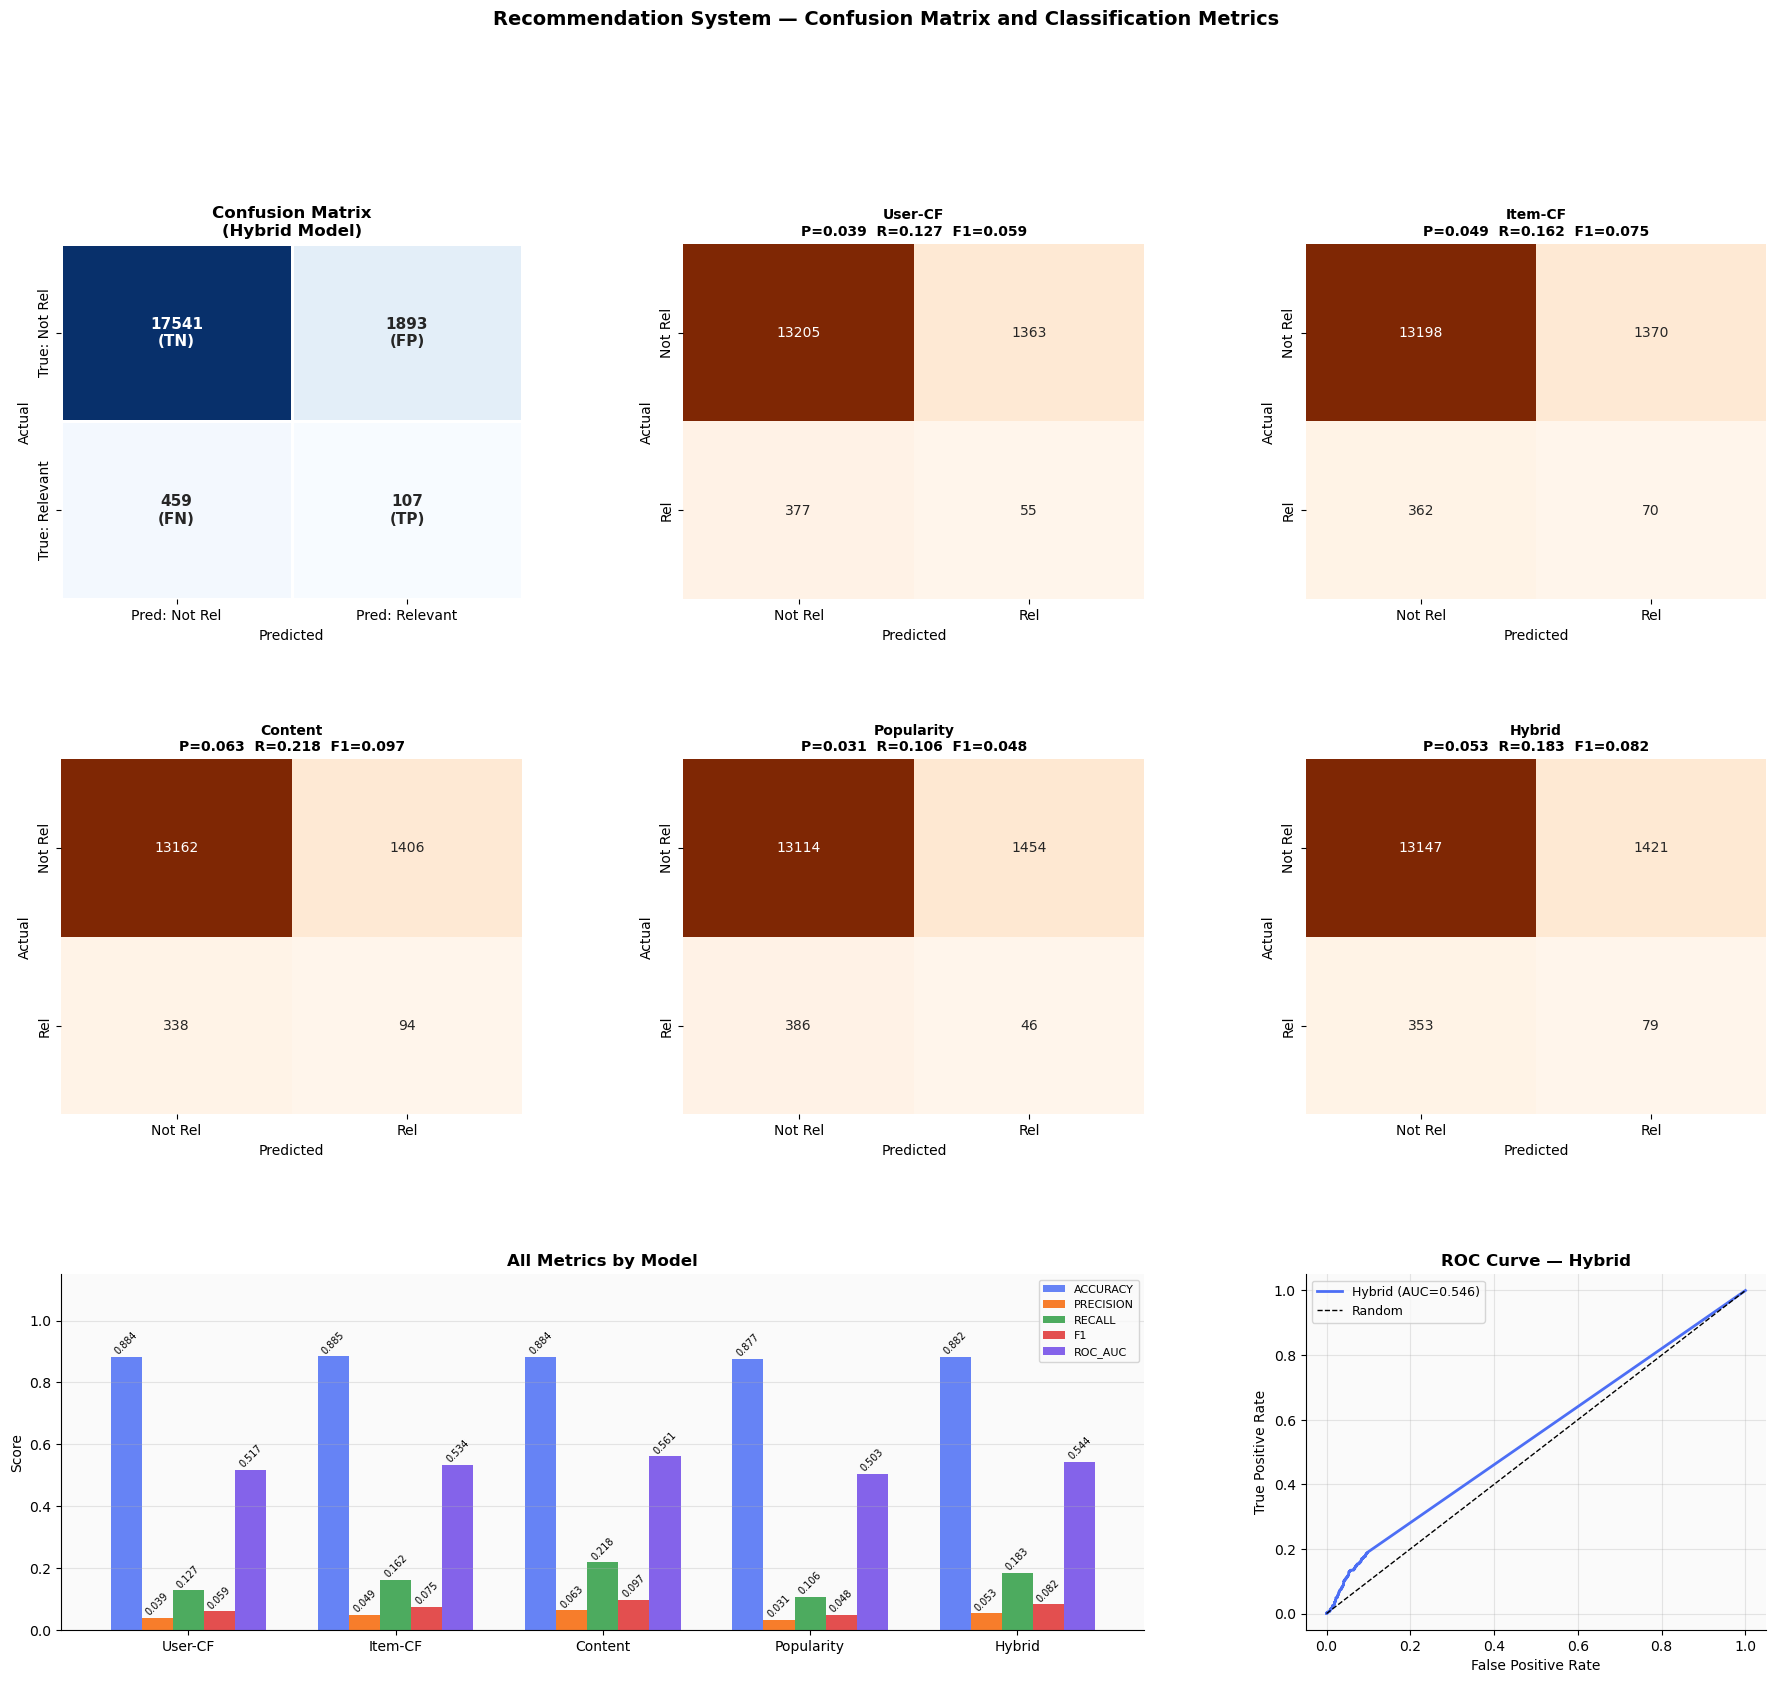

Saved confusion_matrix_report.png

FINAL SUMMARY - ALL MODELS
Model         Accuracy  Precision   Recall      F1  Specificity   ROC-AUC
----------------------------------------------------------------------
User-CF        0.88400    0.03879  0.12731 0.05946      0.90644   0.51749
Item-CF        0.88453    0.04861  0.16204 0.07479      0.90596   0.53418
Content        0.88373    0.06267  0.21759 0.09731      0.90349   0.56098 <- best
Popularity     0.87733    0.03067  0.10648 0.04762      0.90019   0.50309
Hybrid         0.88173    0.05267  0.18287 0.08178      0.90246   0.54364


In [15]:
fig = plt.figure(figsize=(22, 18))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# Main confusion matrix (Hybrid)
ax1    = fig.add_subplot(gs[0, 0])
labels_cm = [['TN', 'FP'], ['FN', 'TP']]
annot  = np.array([[f'{v}\n({lbl})' for v, lbl in zip(row_v, row_l)]
                   for row_v, row_l in zip(cm, labels_cm)])
sns.heatmap(cm, annot=annot, fmt='', cmap='Blues', ax=ax1,
            xticklabels=['Pred: Not Rel', 'Pred: Relevant'],
            yticklabels=['True: Not Rel', 'True: Relevant'],
            linewidths=1, linecolor='white', cbar=False,
            annot_kws={'size': 11, 'weight': 'bold'})
ax1.set_title('Confusion Matrix\n(Hybrid Model)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')

# Per-model confusion matrices
sub_positions = [(0, 1), (0, 2), (1, 0), (1, 1), (1, 2)]
for (r_i, c_i), res in zip(sub_positions, ablation_results):
    ax = fig.add_subplot(gs[r_i, c_i])
    sns.heatmap(res['cm'], annot=True, fmt='d', cmap='Oranges', ax=ax,
                xticklabels=['Not Rel', 'Rel'],
                yticklabels=['Not Rel', 'Rel'],
                cbar=False, annot_kws={'size': 10})
    ax.set_title(f'{res["label"]}\nP={res["precision"]:.3f}  R={res["recall"]:.3f}  '
                 f'F1={res["f1"]:.3f}', fontsize=10, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

# Metrics bar chart
ax_bar = fig.add_subplot(gs[2, 0:2])
model_names  = [r['label'] for r in ablation_results]
metric_names = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
x     = np.arange(len(model_names))
width = 0.15
for i, (m, c) in enumerate(zip(metric_names, PALETTE[:len(metric_names)])):
    vals = [r[m] for r in ablation_results]
    bars = ax_bar.bar(x + i * width, vals, width, label=m.upper(), color=c, alpha=0.85)
    for bar, val in zip(bars, vals):
        ax_bar.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=7, rotation=45)
ax_bar.set_xticks(x + width * 2)
ax_bar.set_xticklabels(model_names)
ax_bar.set_ylim(0, 1.15)
ax_bar.set_title('All Metrics by Model', fontsize=12, fontweight='bold')
ax_bar.set_ylabel('Score')
ax_bar.legend(loc='upper right', fontsize=8)
ax_bar.grid(axis='y', alpha=0.3)

# ROC curve
ax_roc = fig.add_subplot(gs[2, 2])
try:
    fpr_arr, tpr_arr, _ = roc_curve(y_true, y_scores)
    ax_roc.plot(fpr_arr, tpr_arr, color=PALETTE[0], lw=2,
                label=f'Hybrid (AUC={roc_auc:.3f})')
    ax_roc.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
    ax_roc.set_xlabel('False Positive Rate')
    ax_roc.set_ylabel('True Positive Rate')
    ax_roc.set_title('ROC Curve — Hybrid', fontsize=12, fontweight='bold')
    ax_roc.legend(fontsize=9)
    ax_roc.grid(alpha=0.3)
except Exception as e:
    ax_roc.text(0.5, 0.5, f'ROC unavailable\n{e}', ha='center', va='center')

plt.suptitle('Recommendation System — Confusion Matrix and Classification Metrics',
             fontsize=14, fontweight='bold', y=1.01)
plt.savefig('evaluation/confusion_matrix_report.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved confusion_matrix_report.png')

# Final summary
print('\n' + '=' * 70)
print('FINAL SUMMARY - ALL MODELS')
print('=' * 70)
print(f'{"Model":<12} {"Accuracy":>9} {"Precision":>10} {"Recall":>8} '
      f'{"F1":>7} {"Specificity":>12} {"ROC-AUC":>9}')
print('-' * 70)
for r in ablation_results:
    best_marker = ' <- best' if r['f1'] == max(a['f1'] for a in ablation_results) else ''
    print(f'{r["label"]:<12} {r["accuracy"]:>9.5f} {r["precision"]:>10.5f} '
          f'{r["recall"]:>8.5f} {r["f1"]:>7.5f} {r["specificity"]:>12.5f} '
          f'{r["roc_auc"]:>9.5f}{best_marker}')
print('=' * 70)


## 16. Hyperparameter tuning

In [16]:
K_GRID      = [5, 10, 20]
FACTOR_GRID = [20, 35, 49]
TUNE_USERS  = list(test_gt_eval.keys())[:80]

print(f'Grid search over K={K_GRID} x factors={FACTOR_GRID}')
print(f'Using {len(TUNE_USERS)} test users\n')

tune_results = []

for n_factors in FACTOR_GRID:
    n_f = min(n_factors, train_matrix.shape[0]-1, train_matrix.shape[1]-1)
    svd_t = TruncatedSVD(n_components=n_f, n_iter=5, random_state=42)
    uf_t  = svd_t.fit_transform(train_matrix)
    if_t  = svd_t.components_.T

    for k in K_GRID:
        k_u = min(k, len(ALL_USERS)-1)
        k_i = min(k, len(ALL_PRODUCTS)-1)

        knn_u_t = NearestNeighbors(n_neighbors=k_u+1, metric='cosine', algorithm='brute')
        knn_u_t.fit(uf_t)
        knn_i_t = NearestNeighbors(n_neighbors=k_i+1, metric='cosine', algorithm='brute')
        knn_i_t.fit(if_t)

        P_list, R_list, N_list = [], [], []
        for uid in TUNE_USERS:
            rel        = test_gt_eval[uid]
            train_seen = user_seen_train.get(str(uid), set())
            u_idx      = uid2idx.get(str(uid))
            if u_idx is None:
                continue

            # User-CF scores with tuning parameters
            vec          = uf_t[u_idx].reshape(1, -1)
            dists, nb_idx = knn_u_t.kneighbors(vec)
            dists, nb_idx = dists[0], nb_idx[0]
            mask          = nb_idx != u_idx
            sims          = np.clip(1 - dists[mask], 0, 1)
            ucf_scores    = np.dot(sims, train_matrix[nb_idx[mask]]) / (sims.sum() + 1e-9)

            top_j = np.argsort(ucf_scores)[::-1]
            pids  = []
            for j in top_j:
                p = str(ALL_PRODUCTS[j])
                if p not in train_seen:
                    pids.append(p)
                if len(pids) == CONFIG['top_n']:
                    break

            P_list.append(precision_at_k(pids, rel, CONFIG['top_n']))
            R_list.append(recall_at_k(pids, rel, CONFIG['top_n']))
            N_list.append(ndcg_at_k(pids, rel, CONFIG['top_n']))

        tune_results.append({
            'factors': n_f,
            'k':       k,
            'P':       np.mean(P_list),
            'R':       np.mean(R_list),
            'NDCG':    np.mean(N_list),
        })
        print(f'  factors={n_f:2d}  K={k:2d}  '
              f'P@10={np.mean(P_list):.4f}  '
              f'R@10={np.mean(R_list):.4f}  '
              f'NDCG@10={np.mean(N_list):.4f}')

best_tune = max(tune_results, key=lambda x: x['NDCG'])
print(f'\nBest config: factors={best_tune["factors"]}  K={best_tune["k"]}  NDCG={best_tune["NDCG"]:.4f}')


Grid search over K=[5, 10, 20] x factors=[20, 35, 49]
Using 80 test users

  factors=20  K= 5  P@10=0.0400  R@10=0.2146  NDCG@10=0.1046
  factors=20  K=10  P@10=0.0312  R@10=0.1648  NDCG@10=0.0988
  factors=20  K=20  P@10=0.0300  R@10=0.1524  NDCG@10=0.0847
  factors=35  K= 5  P@10=0.0350  R@10=0.1767  NDCG@10=0.1095
  factors=35  K=10  P@10=0.0250  R@10=0.1256  NDCG@10=0.0837
  factors=35  K=20  P@10=0.0350  R@10=0.1560  NDCG@10=0.1020
  factors=49  K= 5  P@10=0.0350  R@10=0.1745  NDCG@10=0.0943
  factors=49  K=10  P@10=0.0350  R@10=0.1737  NDCG@10=0.0893
  factors=49  K=20  P@10=0.0263  R@10=0.1070  NDCG@10=0.0569

Best config: factors=35  K=5  NDCG=0.1095


## 17. Time-series cross-validation

In [17]:
N_SPLITS = 4
CV_USERS  = 60

sorted_ints = interactions_df.sort_values('timestamp').reset_index(drop=True)
fold_size   = len(sorted_ints) // N_SPLITS

print(f'Cross-validation: {N_SPLITS} temporal folds  |  {fold_size:,} events per fold')
print(f'Evaluating on {CV_USERS} users per fold\n')

cv_metrics = []

for fold in range(1, N_SPLITS):
    cv_train = sorted_ints.iloc[:fold * fold_size]
    cv_test  = sorted_ints.iloc[fold * fold_size:(fold + 1) * fold_size]

    cv_agg = cv_train.groupby(['userId', 'productId'])['score'].max().reset_index()
    cv_agg.columns = ['userId', 'productId', 'implicit_score']
    cv_agg['implicit_score'] = cv_agg.groupby('userId')['implicit_score'].transform(minmax_user)
    cv_mat = build_matrix(cv_agg, ALL_USERS, ALL_PRODUCTS, uid2idx, pid2idx)

    cv_svd  = TruncatedSVD(n_components=N_FACTORS, n_iter=5, random_state=42)
    cv_uf   = cv_svd.fit_transform(cv_mat)

    cv_knn_u = NearestNeighbors(n_neighbors=K_user+1, metric='cosine', algorithm='brute')
    cv_knn_u.fit(cv_uf)

    cv_seen = cv_train.groupby('userId')['productId'].apply(set).to_dict()

    cv_gt_raw = cv_test[(cv_test['interaction'] == 'review') &
                        (cv_test['rating'] >= CONFIG['rating_positive_threshold'])]
    cv_gt = cv_gt_raw.groupby('userId')['productId'].apply(set).to_dict()
    cv_gt_eval = {
        str(u): set(str(p) for p in ps)
        for u, ps in cv_gt.items()
        if str(u) in uid2idx and len(ps) > 0
    }

    import random
    random.seed(42)
    cv_sample_users = list(cv_gt_eval.keys())
    if len(cv_sample_users) > CV_USERS:
        cv_sample_users = random.sample(cv_sample_users, CV_USERS)

    P_cv, R_cv, N_cv = [], [], []
    for uid in cv_sample_users:
        rel   = cv_gt_eval[uid]
        u_idx = uid2idx.get(str(uid))
        if u_idx is None:
            continue
        s_seen = cv_seen.get(uid, cv_seen.get(str(uid), set()))
        vec    = cv_uf[u_idx].reshape(1, -1)
        dists, nb_idx = cv_knn_u.kneighbors(vec)
        mask   = nb_idx[0] != u_idx
        sims   = np.clip(1 - dists[0][mask], 0, 1)
        sc     = np.dot(sims, cv_mat[nb_idx[0][mask]]) / (sims.sum() + 1e-9)

        pids = []
        for j in np.argsort(sc)[::-1]:
            p = str(ALL_PRODUCTS[j])
            if p not in set(str(x) for x in s_seen):
                pids.append(p)
            if len(pids) == CONFIG['top_n']:
                break

        P_cv.append(precision_at_k(pids, rel, CONFIG['top_n']))
        R_cv.append(recall_at_k(pids, rel, CONFIG['top_n']))
        N_cv.append(ndcg_at_k(pids, rel, CONFIG['top_n']))

    cv_metrics.append({
        'fold': fold,
        'P':    np.mean(P_cv) if P_cv else 0,
        'R':    np.mean(R_cv) if R_cv else 0,
        'NDCG': np.mean(N_cv) if N_cv else 0,
        'n':    len(P_cv),
    })
    print(f'  Fold {fold}  n={len(P_cv)}  '
          f'P@10={cv_metrics[-1]["P"]:.4f}  '
          f'R@10={cv_metrics[-1]["R"]:.4f}  '
          f'NDCG@10={cv_metrics[-1]["NDCG"]:.4f}')

if cv_metrics:
    print(f'\nMean across folds:  '
          f'P@10={np.mean([m["P"] for m in cv_metrics]):.4f}  '
          f'R@10={np.mean([m["R"] for m in cv_metrics]):.4f}  '
          f'NDCG@10={np.mean([m["NDCG"] for m in cv_metrics]):.4f}')


Cross-validation: 4 temporal folds  |  19,755 events per fold
Evaluating on 60 users per fold

  Fold 1  n=60  P@10=0.0133  R@10=0.0722  NDCG@10=0.0465
  Fold 2  n=60  P@10=0.0267  R@10=0.0794  NDCG@10=0.0630
  Fold 3  n=60  P@10=0.0167  R@10=0.0944  NDCG@10=0.0588

Mean across folds:  P@10=0.0189  R@10=0.0820  NDCG@10=0.0561


## 18. Save the trained model

In [18]:
model_bundle = {
    'knn_user':         knn_user,
    'knn_item':         knn_item,
    'svd_model':        svd_model,
    'user_factors':     user_factors,
    'item_factors':     item_factors,
    'P_pp': P_pp, 'Q_pp': Q_pp, 'Y_pp': Y_pp,
    'bu_pp': bu_pp, 'bi_pp': bi_pp,
    'MU_GLOBAL':        MU_GLOBAL,
    'Pu_fm': Pu_fm, 'Qi_fm': Qi_fm,
    'Au_fm': Au_fm, 'Bi_fm': Bi_fm,
    'tfidf_vec':        tfidf_vec,
    'content_sim':      content_sim,
    'tfidf_pids':       tfidf_pids,
    'tfidf_pid2idx':    tfidf_pid2idx,
    'popularity_scores': popularity_scores,
    'ALL_USERS':        ALL_USERS,
    'ALL_PRODUCTS':     ALL_PRODUCTS,
    'uid2idx':          uid2idx,
    'pid2idx':          pid2idx,
    'user_seen':        user_seen,
    'user_seen_train':  user_seen_train,
    'user_feat_mat':    user_feat_mat,
    'item_text_mat':    item_text_mat,
    'K_PP':             K_PP,
    'LF':               LF,
    'N_PERSONA':        N_PERSONA,
    'le_persona':       le_persona,
    'user_implicit_items': user_implicit_items,
    'CONFIG':           CONFIG,
    'eval_metrics':     eval_metrics,
}

model_path = 'models/recommendation_model.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(model_bundle, f)

size_mb = os.path.getsize(model_path) / (1024 * 1024)
print(f'Model saved to {model_path}  ({size_mb:.1f} MB)')
print(f'Keys saved: {len(model_bundle)}')


Model saved to models/recommendation_model.pkl  (5.5 MB)
Keys saved: 35
